In [109]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
    }
)

print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Load and Explore the Dataset



In [110]:
BASE_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
DATA_PATH = BASE_DIR / "Dataset" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df_raw = pd.read_csv(DATA_PATH)

print(f"Shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head()

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [111]:
print("=== Data Types ===")
print(df_raw.dtypes)

print("\n=== Missing Values Reported by pandas ===")
print(df_raw.isnull().sum())

print("\n=== Churn Distribution ===")
print(df_raw["Churn"].value_counts())
print(df_raw["Churn"].value_counts(normalize=True).round(4))

=== Data Types ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== Missing Values Reported by pandas ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contra

## Preprocessing



In [112]:
X_raw = df_raw.drop(columns=["customerID", "Churn"]).copy()
X_raw["TotalCharges"] = pd.to_numeric(X_raw["TotalCharges"], errors="coerce")
y = df_raw["Churn"].map({"No": 0, "Yes": 1})

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

numeric_columns = X_train_raw.select_dtypes(include=np.number).columns.tolist()
categorical_columns = X_train_raw.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numeric_columns,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            drop="first",
                            handle_unknown="ignore",
                            sparse_output=False,
                        ),
                    ),
                ]
            ),
            categorical_columns,
        ),
    ],
    verbose_feature_names_out=False,
)

X_train_array = preprocessor.fit_transform(X_train_raw)
X_test_array = preprocessor.transform(X_test_raw)
feature_names = preprocessor.get_feature_names_out()

X_train = pd.DataFrame(
    X_train_array,
    columns=feature_names,
    index=X_train_raw.index,
)
X_test = pd.DataFrame(
    X_test_array,
    columns=feature_names,
    index=X_test_raw.index,
)

# StandardScaler is applied only to continuous numerical features.
# SeniorCitizen is already a binary 0/1 indicator.
CONTINUOUS_COLUMNS = ["tenure", "MonthlyCharges", "TotalCharges"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[CONTINUOUS_COLUMNS] = scaler.fit_transform(
    X_train[CONTINUOUS_COLUMNS]
)
X_test_scaled[CONTINUOUS_COLUMNS] = scaler.transform(
    X_test[CONTINUOUS_COLUMNS]
)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}")
print(f"Test churn rate: {y_test.mean():.3f}")
print(f"Number of encoded features: {X_train.shape[1]}")

Train size: (5634, 30)
Test size: (1409, 30)
Train churn rate: 0.265
Test churn rate: 0.265
Number of encoded features: 30


## 3. Helper Functions



In [113]:
SVM_SHARED_PARAMS = {
    "class_weight": {0: 1.0, 1: 1.5},
    "gamma": "scale",
    "cache_size": 1000,
    # -1 allows libsvm to continue until convergence.
    "max_iter": -1,
}

print("Shared SVM parameters:")
print(SVM_SHARED_PARAMS)

def get_metrics(y_true, y_pred, y_score):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score),
    }


def run_svm(X_tr, X_te, y_tr, y_te, **kwargs):
    model_params = {
        **SVM_SHARED_PARAMS,
        **kwargs,
    }

    model = SVC(
        random_state=42,
        **model_params,
    )
    model.fit(X_tr, y_tr)

    train_pred = model.predict(X_tr)
    test_pred = model.predict(X_te)
    test_score = model.decision_function(X_te)

    return {
        "model": model,
        "train_accuracy": accuracy_score(y_tr, train_pred),
        "y_pred": test_pred,
        "y_score": test_score,
        "metrics": get_metrics(y_te, test_pred, test_score),
    }


def print_result(title, result):
    test_accuracy = result["metrics"]["Accuracy"]

    print(f"=== {title} ===")
    print(f"Train Accuracy: {result['train_accuracy']:.4f}")
    print(f"Test Accuracy : {test_accuracy:.4f}")
    print(f"Accuracy Gap  : {result['train_accuracy'] - test_accuracy:.4f}")

    for metric, value in result["metrics"].items():
        print(f"{metric:<12}: {value:.4f}")


def plot_metrics_bar(results, title, figsize=(10, 4)):
    labels = list(results.keys())
    metric_names = list(next(iter(results.values())).keys())
    x = np.arange(len(metric_names))
    width = 0.8 / len(labels)

    fig, ax = plt.subplots(figsize=figsize)

    for index, (label, metrics) in enumerate(results.items()):
        values = [metrics[name] for name in metric_names]
        bars = ax.bar(
            x + index * width,
            values,
            width,
            label=label,
            alpha=0.85,
        )

        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{value:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    ax.set_xticks(x + width * (len(labels) - 1) / 2)
    ax.set_xticklabels(metric_names)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel("Score")
    ax.set_title(title)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


def plot_confusion_matrices(results, title):
    n = len(results)

    cols = 3
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(5 * cols, 4 * rows)
    )

    axes = np.array(axes).flatten()

    for ax, (label, result) in zip(axes, results.items()):
        matrix = confusion_matrix(
            y_test,
            result["y_pred"]
        )

        display = ConfusionMatrixDisplay(
            matrix,
            display_labels=["No Churn", "Churn"]
        )

        display.plot(
            ax=ax,
            cmap="Blues",
            colorbar=False,
            values_format="d"
        )

        ax.set_title(label)
    for ax in axes[n:]:
        ax.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_roc(roc_data, title):
    fig, ax = plt.subplots(figsize=(6, 5))

    for label, (false_positive_rate, true_positive_rate, auc_value) in roc_data.items():
        ax.plot(
            false_positive_rate,
            true_positive_rate,
            linewidth=2,
            label=f"{label} (AUC={auc_value:.3f})",
        )

    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


print("Helper functions defined")



Shared SVM parameters:
{'class_weight': {0: 1.0, 1: 1.5}, 'gamma': 'scale', 'cache_size': 1000, 'max_iter': -1}
Helper functions defined


## Scenario 1 - Baseline Regularized SVM


In [114]:
baseline_result = run_svm(
    X_train,
    X_test,
    y_train,
    y_test,
    kernel="rbf",
    C=1.0,
)

print_result("Scenario 1 - Baseline Regularized SVM", baseline_result)
print()
print(
    classification_report(
        y_test,
        baseline_result["y_pred"],
        target_names=["No Churn", "Churn"],
    )
)

=== Scenario 1 - Baseline Regularized SVM ===
Train Accuracy: 0.7563
Test Accuracy : 0.7729
Accuracy Gap  : -0.0166
Accuracy    : 0.7729
Precision   : 0.6227
Recall      : 0.3663
F1-Score    : 0.4613
ROC-AUC     : 0.7658

              precision    recall  f1-score   support

    No Churn       0.80      0.92      0.86      1035
       Churn       0.62      0.37      0.46       374

    accuracy                           0.77      1409
   macro avg       0.71      0.64      0.66      1409
weighted avg       0.75      0.77      0.75      1409



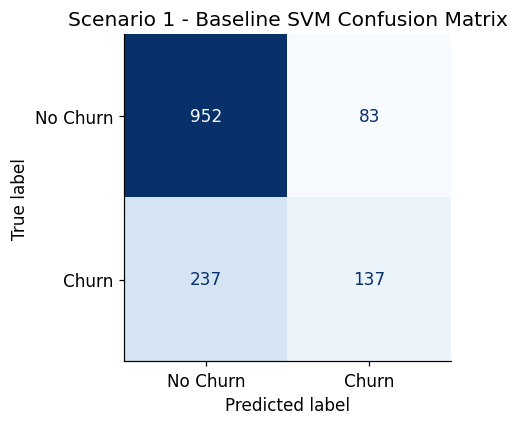

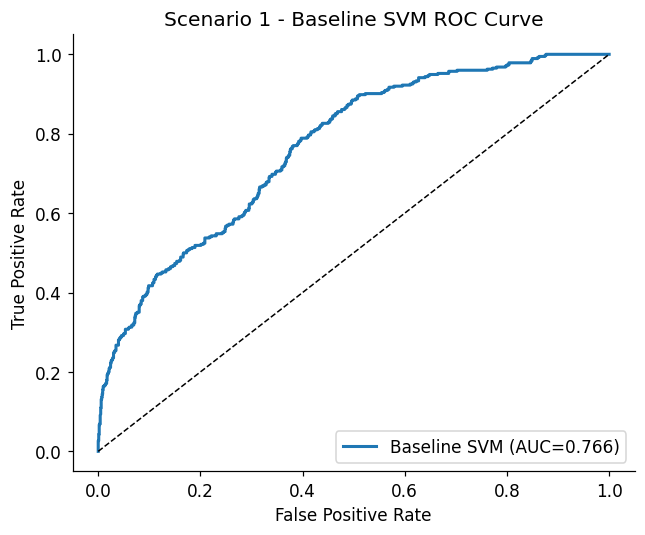

In [115]:
plot_confusion(
    y_test,
    baseline_result["y_pred"],
    "Scenario 1 - Baseline SVM Confusion Matrix",
)

baseline_fpr, baseline_tpr, _ = roc_curve(
    y_test,
    baseline_result["y_score"],
)
plot_roc(
    {
        "Baseline SVM": (
            baseline_fpr,
            baseline_tpr,
            baseline_result["metrics"]["ROC-AUC"],
        )
    },
    "Scenario 1 - Baseline SVM ROC Curve",
)

## Scenario 2 - Feature Scaling Comparison



In [116]:
no_scaling_result = run_svm(
    X_train,
    X_test,
    y_train,
    y_test,
    kernel="rbf",
    C=1.0,
)

scaling_result = run_svm(
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    kernel="rbf",
    C=1.0,
)

print_result("Scenario 2A - No Scaling", no_scaling_result)
print()
print_result("Scenario 2B - StandardScaler", scaling_result)

=== Scenario 2A - No Scaling ===
Train Accuracy: 0.7563
Test Accuracy : 0.7729
Accuracy Gap  : -0.0166
Accuracy    : 0.7729
Precision   : 0.6227
Recall      : 0.3663
F1-Score    : 0.4613
ROC-AUC     : 0.7658

=== Scenario 2B - StandardScaler ===
Train Accuracy: 0.8117
Test Accuracy : 0.7828
Accuracy Gap  : 0.0289
Accuracy    : 0.7828
Precision   : 0.5817
Recall      : 0.6471
F1-Score    : 0.6127
ROC-AUC     : 0.8141


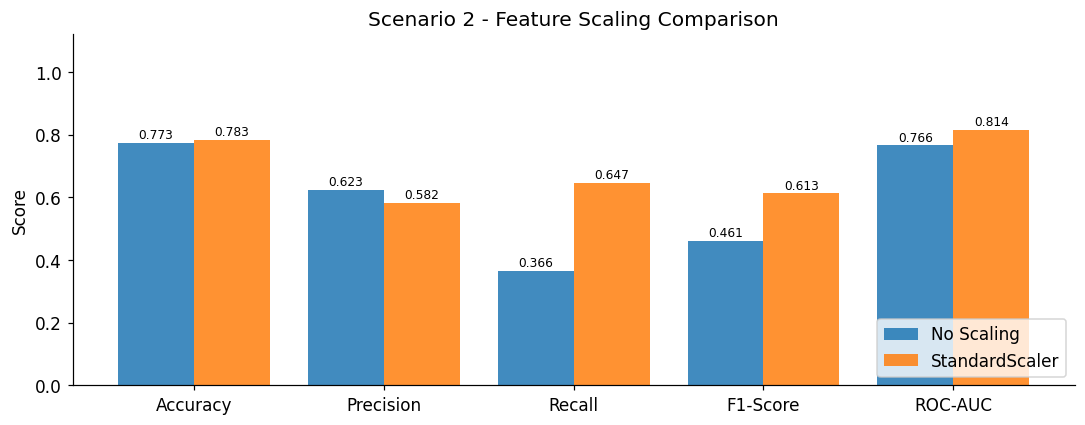

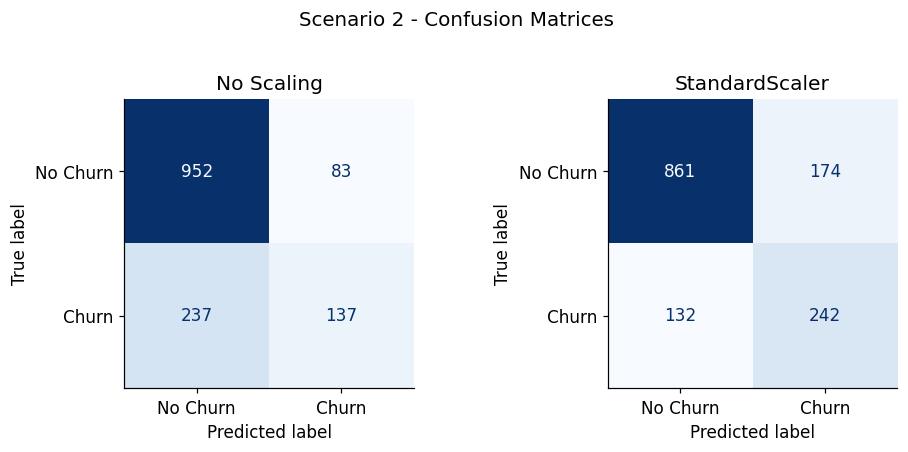

In [117]:
scenario_2_metrics = {
    "No Scaling": no_scaling_result["metrics"],
    "StandardScaler": scaling_result["metrics"],
}

plot_metrics_bar(
    scenario_2_metrics,
    "Scenario 2 - Feature Scaling Comparison",
)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, (label, result) in zip(
    axes,
    [
        ("No Scaling", no_scaling_result),
        ("StandardScaler", scaling_result),
    ],
):
    matrix = confusion_matrix(y_test, result["y_pred"])
    display = ConfusionMatrixDisplay(
        matrix,
        display_labels=["No Churn", "Churn"],
    )
    display.plot(
        ax=ax,
        colorbar=False,
        cmap="Blues",
        values_format="d",
    )
    ax.set_title(label)

plt.suptitle("Scenario 2 - Confusion Matrices", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

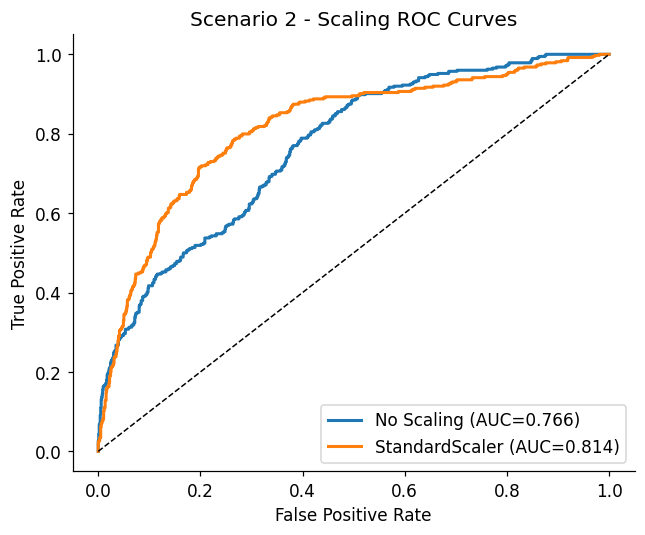

In [118]:
scenario_2_roc = {}

for label, result in [
    ("No Scaling", no_scaling_result),
    ("StandardScaler", scaling_result),
]:
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test,
        result["y_score"],
    )
    scenario_2_roc[label] = (
        false_positive_rate,
        true_positive_rate,
        result["metrics"]["ROC-AUC"],
    )

plot_roc(
    scenario_2_roc,
    "Scenario 2 - Scaling ROC Curves",
)


In [119]:
print("=== Scenario 2 Metric Differences: Scaling - No Scaling ===")

for metric in no_scaling_result["metrics"]:
    difference = (
        scaling_result["metrics"][metric]
        - no_scaling_result["metrics"][metric]
    )
    print(f"{metric:<12}: {difference:+.4f}")

print(
    "\nConclusion: scaling is important for the RBF SVM because distance "
    "calculations are sensitive to feature magnitude."
)


=== Scenario 2 Metric Differences: Scaling - No Scaling ===
Accuracy    : +0.0099
Precision   : -0.0410
Recall      : +0.2807
F1-Score    : +0.1514
ROC-AUC     : +0.0483

Conclusion: scaling is important for the RBF SVM because distance calculations are sensitive to feature magnitude.


## Scenario 3 - 'C' and Gamma comparison




In [120]:
kernels = ["linear", "rbf"]
c_values = [0.1, 1, 10]
gamma_values = [0.001, 0.01, 0.1, 1]
scenario_3_results = {}

for kernel in kernels:
    for c_value in c_values:
        for gamma_value in gamma_values:
            label = f"{kernel}, C={c_value}, gamma={gamma_value}"
            scenario_3_results[label] = run_svm(
                X_train_scaled,
                X_test_scaled,
                y_train,
                y_test,
                kernel=kernel,
                C=c_value,
                gamma=gamma_value
            )

print(
    f"{'Model':<18}"
    f"{'Train Acc':>12}"
    f"{'Test Acc':>12}"
    f"{'Gap':>10}"
    f"{'Precision':>12}"
    f"{'Recall':>10}"
    f"{'F1':>10}"
    f"{'ROC-AUC':>10}"
)
print("-" * 94)

for label, result in scenario_3_results.items():
    train_accuracy = result["train_accuracy"]
    test_accuracy = result["metrics"]["Accuracy"]

    print(
        f"{label:<18}"
        f"{train_accuracy:>12.4f}"
        f"{test_accuracy:>12.4f}"
        f"{train_accuracy - test_accuracy:>10.4f}"
        f"{result['metrics']['Precision']:>12.4f}"
        f"{result['metrics']['Recall']:>10.4f}"
        f"{result['metrics']['F1-Score']:>10.4f}"
        f"{result['metrics']['ROC-AUC']:>10.4f}"
    )


Model                Train Acc    Test Acc       Gap   Precision    Recall        F1   ROC-AUC
----------------------------------------------------------------------------------------------
linear, C=0.1, gamma=0.001      0.7930      0.7793    0.0138      0.5752    0.6444    0.6078    0.8361
linear, C=0.1, gamma=0.01      0.7930      0.7793    0.0138      0.5752    0.6444    0.6078    0.8361
linear, C=0.1, gamma=0.1      0.7930      0.7793    0.0138      0.5752    0.6444    0.6078    0.8361
linear, C=0.1, gamma=1      0.7930      0.7793    0.0138      0.5752    0.6444    0.6078    0.8361
linear, C=1, gamma=0.001      0.7914      0.7786    0.0129      0.5738    0.6444    0.6071    0.8361
linear, C=1, gamma=0.01      0.7914      0.7786    0.0129      0.5738    0.6444    0.6071    0.8361
linear, C=1, gamma=0.1      0.7914      0.7786    0.0129      0.5738    0.6444    0.6071    0.8361
linear, C=1, gamma=1      0.7914      0.7786    0.0129      0.5738    0.6444    0.6071    0.8361
linear, 

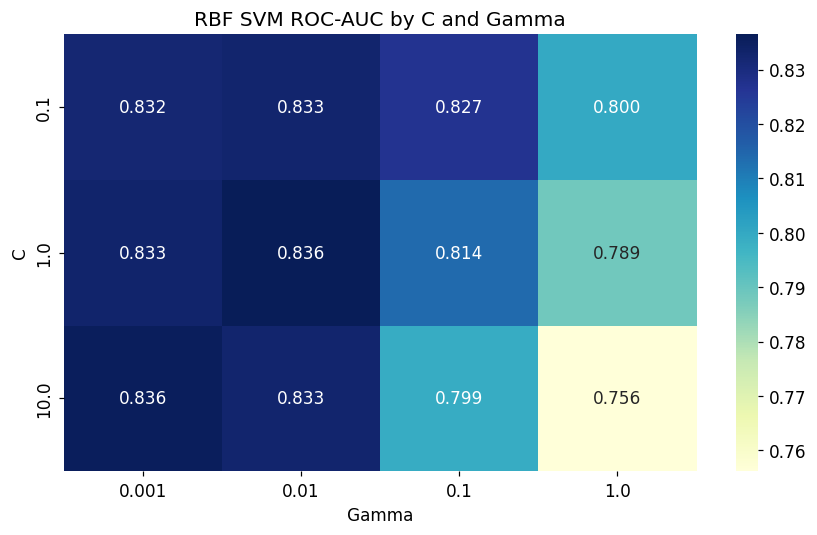

In [121]:

rows = []

for label, result in scenario_3_results.items():
    if "rbf" not in label:
        continue

    parts = label.split(", ")

    rows.append({
        "C": float(parts[1].split("=")[1]),
        "Gamma": float(parts[2].split("=")[1]),
        "ROC-AUC": result["metrics"]["ROC-AUC"]
    })

df = pd.DataFrame(rows)

pivot = df.pivot(
    index="C",
    columns="Gamma",
    values="ROC-AUC"
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu"
)

plt.title("RBF SVM ROC-AUC by C and Gamma")
plt.ylabel("C")
plt.xlabel("Gamma")

plt.tight_layout()
plt.show()

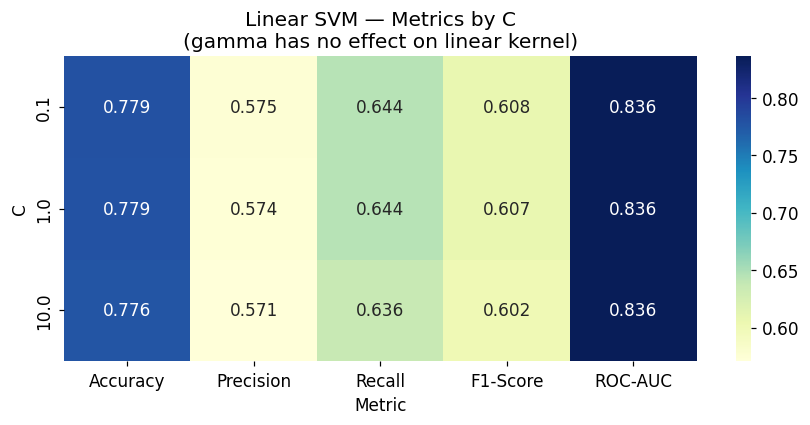

In [131]:
rows = []
for label, result in scenario_3_results.items():
    if "linear" not in label:
        continue
    parts = label.split(", ")
    row = {"C": float(parts[1].split("=")[1])}
    row.update(result["metrics"])
    rows.append(row)

df_linear = pd.DataFrame(rows).drop_duplicates(subset="C").set_index("C")

plt.figure(figsize=(8, 4))
sns.heatmap(
    df_linear,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
)
plt.title("Linear SVM — Metrics by C\n(gamma has no effect on linear kernel)")
plt.ylabel("C")
plt.xlabel("Metric")
plt.tight_layout()
plt.show()

In [122]:
linear_results = {
    label: result
    for label, result in scenario_3_results.items()
    if label.startswith("linear")
}

rbf_results = {
    label: result
    for label, result in scenario_3_results.items()
    if label.startswith("rbf")
}

best_linear = max(
    linear_results.items(),
    key=lambda x: x[1]["metrics"]["ROC-AUC"]
)

best_rbf = max(
    rbf_results.items(),
    key=lambda x: x[1]["metrics"]["ROC-AUC"]
)

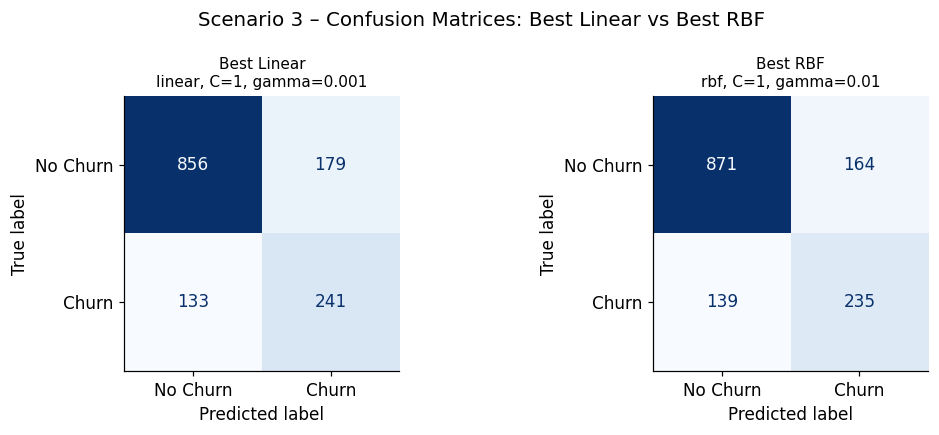

In [123]:
best_linear_label, best_linear_result = best_linear
best_rbf_label,    best_rbf_result    = best_rbf

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (label, result) in zip(
    axes,
    [
        (f"Best Linear\n{best_linear_label}", best_linear_result),
        (f"Best RBF\n{best_rbf_label}",       best_rbf_result),
    ],
):
    matrix = confusion_matrix(y_test, result["y_pred"])
    display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["No Churn", "Churn"],
    )
    display.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(label, fontsize=10)

plt.suptitle(
    "Scenario 3 – Confusion Matrices: Best Linear vs Best RBF",
    fontsize=13,
)
plt.tight_layout()
plt.show()


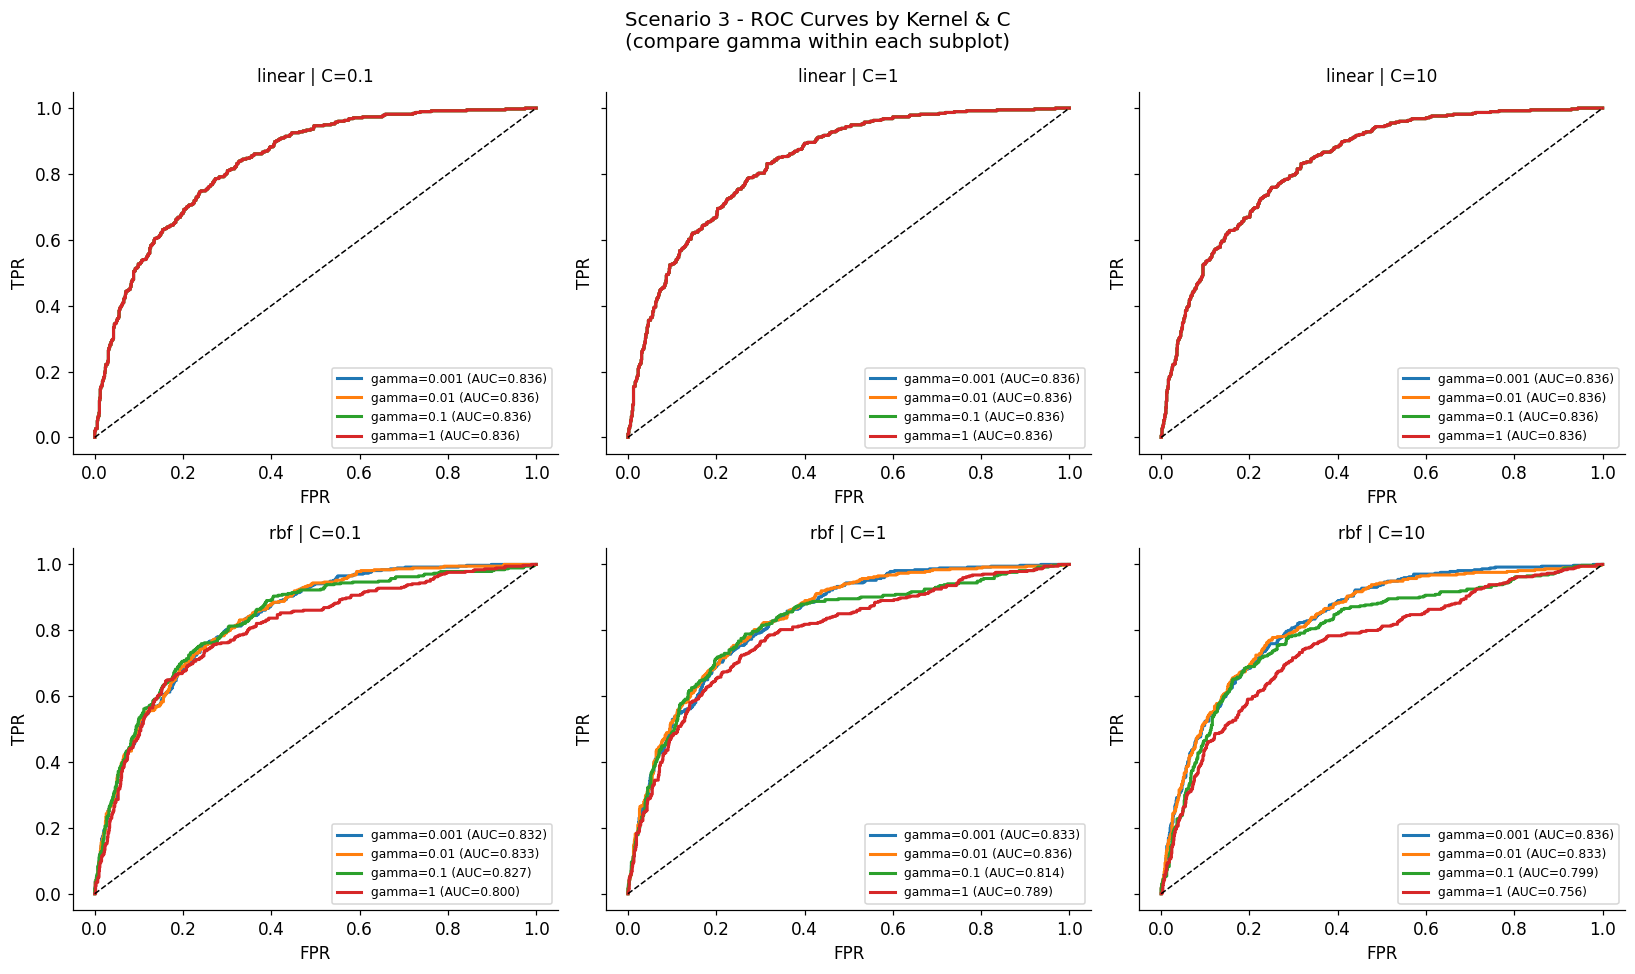

In [130]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

for ax, (kernel, c_val) in zip(
    axes.flatten(),
    [(k, c) for k in ["linear", "rbf"] for c in [0.1, 1, 10]],
):
    for label, result in scenario_3_results.items():
        if not (label.startswith(kernel) and f"C={c_val}," in label):
            continue
        gamma_str = label.split(", ")[2]  # 'gamma=0.001'
        fpr, tpr, _ = roc_curve(y_test, result["y_score"])
        auc = result["metrics"]["ROC-AUC"]
        ax.plot(fpr, tpr, linewidth=2, label=f"{gamma_str} (AUC={auc:.3f})")

    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_title(f"{kernel} | C={c_val}", fontsize=11)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.legend(loc="lower right", fontsize=8)

plt.suptitle(
    "Scenario 3 - ROC Curves by Kernel & C\n(compare gamma within each subplot)",
    fontsize=13,
)
plt.tight_layout()
plt.show()

## SVM Coefficient Magnitudes

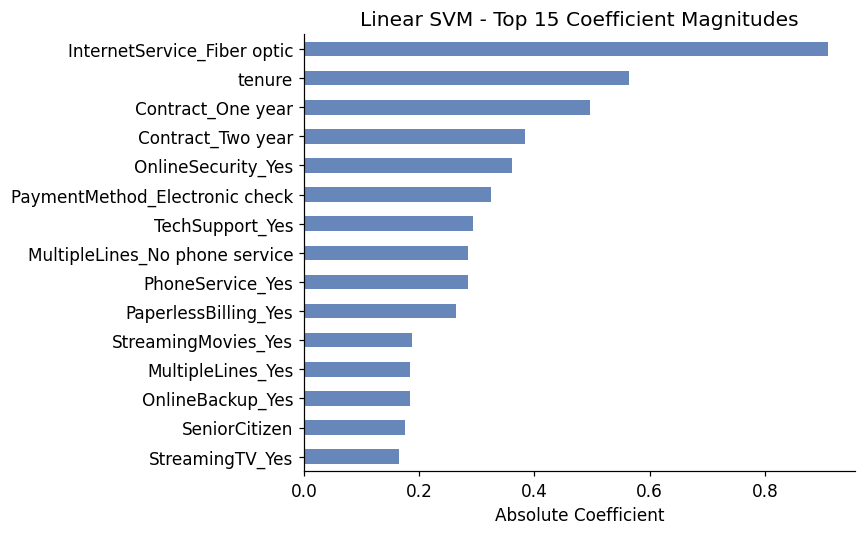

In [125]:
linear_reference = scenario_3_results["linear, C=0.1, gamma=1"]
linear_importance = pd.Series(
    np.abs(linear_reference["model"].coef_).ravel(),
    index=X_train_scaled.columns,
)
top_15_linear_features = linear_importance.nlargest(15)

fig, ax = plt.subplots(figsize=(8, 5))
top_15_linear_features.sort_values().plot(
    kind="barh",
    ax=ax,
    color="#4C72B0",
    alpha=0.85,
)
ax.set_title("Linear SVM - Top 15 Coefficient Magnitudes")
ax.set_xlabel("Absolute Coefficient")
plt.tight_layout()
plt.show()


## Summary



In [126]:
all_results = {
    "S1 - Baseline": baseline_result["metrics"],
    "S2A - No Scaling": no_scaling_result["metrics"],
    "S2B - Scaling": scaling_result["metrics"],
}

for label, result in scenario_3_results.items():
    all_results[f"S3 - {label}"] = result["metrics"]

summary_df = pd.DataFrame(all_results).T.round(4)
print(summary_df.to_string())


                                 Accuracy  Precision  Recall  F1-Score  ROC-AUC
S1 - Baseline                      0.7729     0.6227  0.3663    0.4613   0.7658
S2A - No Scaling                   0.7729     0.6227  0.3663    0.4613   0.7658
S2B - Scaling                      0.7828     0.5817  0.6471    0.6127   0.8141
S3 - linear, C=0.1, gamma=0.001    0.7793     0.5752  0.6444    0.6078   0.8361
S3 - linear, C=0.1, gamma=0.01     0.7793     0.5752  0.6444    0.6078   0.8361
S3 - linear, C=0.1, gamma=0.1      0.7793     0.5752  0.6444    0.6078   0.8361
S3 - linear, C=0.1, gamma=1        0.7793     0.5752  0.6444    0.6078   0.8361
S3 - linear, C=1, gamma=0.001      0.7786     0.5738  0.6444    0.6071   0.8361
S3 - linear, C=1, gamma=0.01       0.7786     0.5738  0.6444    0.6071   0.8361
S3 - linear, C=1, gamma=0.1        0.7786     0.5738  0.6444    0.6071   0.8361
S3 - linear, C=1, gamma=1          0.7786     0.5738  0.6444    0.6071   0.8361
S3 - linear, C=10, gamma=0.001     0.776

                                Accuracy  Precision  Recall  F1-Score  ROC-AUC
S1 - Baseline                     0.7729     0.6227  0.3663    0.4613   0.7658
S2A - No Scaling                  0.7729     0.6227  0.3663    0.4613   0.7658
S2B - Scaling                     0.7828     0.5817  0.6471    0.6127   0.8141
linear | C=0.1 | gamma=0.001 ★    0.7793     0.5752  0.6444    0.6078   0.8361
linear | C=1 | gamma=0.001 ★      0.7786     0.5738  0.6444    0.6071   0.8361
linear | C=10 | gamma=0.001 ★     0.7764     0.5707  0.6364    0.6018   0.8355
rbf | C=0.1 | gamma=0.01 ★        0.7786     0.5799  0.6016    0.5906   0.8328
rbf | C=1 | gamma=0.01 ★          0.7850     0.5890  0.6283    0.6080   0.8365
rbf | C=10 | gamma=0.001 ★        0.7835     0.5844  0.6390    0.6105   0.8356


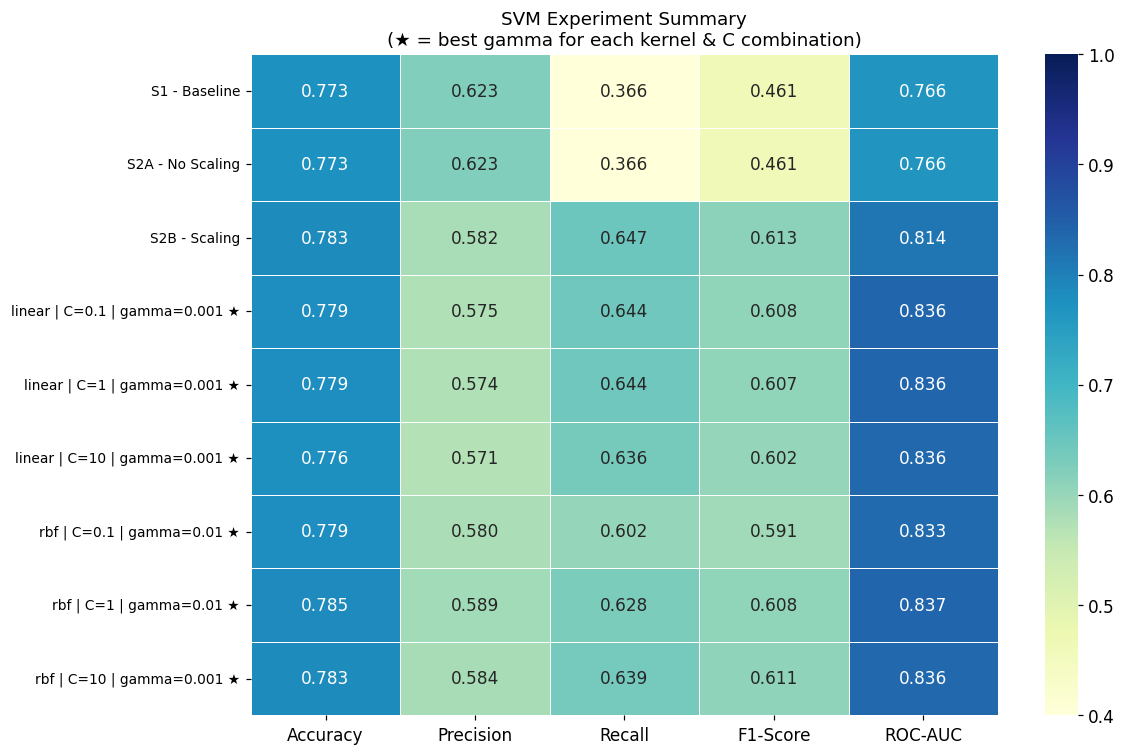

In [127]:
# Summary heatmap: S1/S2 baselines + best gamma per (kernel, C) combo
best_s3_results = {}
for kernel in ["linear", "rbf"]:
    for c_val in [0.1, 1, 10]:
        c_str = f"C={c_val}"
        candidates = {
            label: result
            for label, result in scenario_3_results.items()
            if label.startswith(kernel) and f"C={c_val}," in label
        }
        best_label, best_result = max(
            candidates.items(),
            key=lambda x: x[1]["metrics"]["ROC-AUC"],
        )
        # Extract gamma from label e.g. "linear, C=0.1, gamma=0.001"
        gamma_str = best_label.split(", ")[2]  # 'gamma=0.001'
        row_label = f"{kernel} | {c_str} | {gamma_str} ★"
        best_s3_results[row_label] = best_result["metrics"]

summary_results = {
    "S1 - Baseline":    baseline_result["metrics"],
    "S2A - No Scaling": no_scaling_result["metrics"],
    "S2B - Scaling":    scaling_result["metrics"],
    **best_s3_results,
}

summary_df = pd.DataFrame(summary_results).T.round(4)
print(summary_df.to_string())

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(
    summary_df,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=ax,
    vmin=0.4,
    vmax=1.0,
)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_title(
    "SVM Experiment Summary\n"
    "(★ = best gamma for each kernel & C combination)",
    fontsize=12,
)
plt.tight_layout()
plt.show()